# Everything the strait holds

The other quickstart names its sources. This one doesn't: **one bare `discover()`** sweeps
every registered source — both countries, every agency, the research networks you would not
think to name — and the pipeline runs on whatever comes back. Tide gauges at six minutes,
weather at an hour and a day, a river at fifteen minutes, ship-lowered bottle casts with
nutrients, and a satellite chlorophyll grid, all in one tree, one matrix, one model, one
citation block.

Everything ran live; every number in the prose is printed by the cell above it.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import omnisea

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 150)

SITE = omnisea.Site(48.30, -123.53, "Juan de Fuca", radius_km=45)
WINDOW = ("2024-06-01", "2024-07-01")
print(f"omnisea {omnisea.__version__} — {len(omnisea.sources())} sources, "
      f"{len(omnisea.providers())} organizations, no providers= anywhere below")

omnisea 0.1.0 — 43 sources, 18 organizations, no providers= anywhere below


## 1. Discover with no `providers=` at all

Every source that covers this corner of the Pacific answers. The catalogue is the map of what
exists — and the row estimate is the argument for looking before fetching.

In [2]:
cat = omnisea.discover(sites=SITE, time=WINDOW)
frame = cat.describe()
print(f"{len(cat)} stations from {frame['source'].nunique()} sources, "
      f"~{cat.n_rows_est:,} rows if all of it were fetched\n")
print(frame.groupby("source")
      .agg(stations=("station_id", "count"), nearest_km=("distance_km", "min"))
      .sort_values("nearest_km").to_string())

305 stations from 18 sources, ~1,185,639,442 rows if all of it were fetched

                               stations  nearest_km
source                                             
cioos_pacific_tabledap                5        0.00
osmc_tabledap                         4        0.00
ioos_sensors_tabledap                19        0.00
hakai_griddap                         2        0.00
glider_dac_tabledap                   1        0.00
eccc_climate                         12        0.25
eccc_climate_daily                   13        0.25
eccc_climate_monthly                104        0.25
dfo_tides                            24        3.83
eccc_hydrometric_monthly             28        7.04
eccc_hydrometric_daily               28        7.04
eccc_hydrometric_annual_peaks        28        7.04
eccc_hydrometric_annual              28        7.04
salishseacast_tabledap                1        9.36
noaa_coops                            1       20.57
usgs_water                            2

A billion-row estimate is not a mistake — it is mostly one satellite grid
priced by its cells — and it is why the workflow is *catalogue first*: keep the *nearest
station per source* and fetch that. (Ocean Networks Canada would join this list with a free
API token; nothing else below needs any credential.)

In [3]:
tree = cat.filter(nearest=1).fetch(on_error="collect")
print(omnisea.describe(tree)[["node", "station_name", "n_time"]].to_string(index=False))

/Users/dexterfichuk/Projects/oceanhackweek-26/omnisea/src/omnisea/providers/erddap/table.py:94: UserWarning: IOS_BOT_Profiles returns 83 row(s) that share a timestamp with another row of the same series, and omnisea cannot tell them apart: the dataset identifies its series by (nothing) and that is not unique per instant. One row per timestamp is kept and the rest are dropped, so any column here may be interleaving two instruments. Narrow the request until each timestamp is unique (a depth= range, or erddap_datasets= a single-series dataset).
  lambda m: self._fetch_dataset(query, m),


                                          node                                     station_name  n_time
/in_situ/erddap/cioos_pacific/IOS_BOT_Profiles                          IOS Rosette Bottle Data       9
                 /predictions/tides_hilo/07080                                       Pedder Bay      76
                      /in_situ/weather/1016640                                       RACE ROCKS     721
                /in_situ/weather_daily/1016640                                       RACE ROCKS      31
     /gridded/erddap/hakai/sentinel_3A_POLYMER                                              NaN      27
                        /in_situ/tides/9444090                                     Port Angeles    7201
               /predictions/tides_hilo/9444090                                     Port Angeles      98
                 /in_situ/hydrometric/12045500 ELWHA RIVER AT MCDONALD BR NEAR PORT ANGELES, WA    2881
           /in_situ/hydrometric_daily/12045500 ELWHA RIVER AT MC

Read the `n_time` column as sampling grains: **7,201** six-minute water
levels, **2,881** fifteen-minute river readings, **721** hourly weather rows, **31** daily
summaries, **76–98** predicted tide extrema, **9** bottle casts, and a **27**-scene satellite
grid that stayed *lazy* — its billion cells cost nothing until read. Sources whose nearest
station had no rows this month simply contributed no node; an empty answer is an answer, and
`citation()` will say so at the end.

## 2. The satellite joins as one pixel

`align()` refuses to flatten a 451×452 grid into a time series and says what to do instead:
pick the cells you want, then `add_local()` the result. One `.sel()` reads a single pixel's
chlorophyll history over the site.

In [4]:
grid = tree["/gridded/erddap/hakai/sentinel_3A_POLYMER"].dataset
pixel = grid.sel(latitude=SITE.lat, longitude=SITE.lon, method="nearest")
chl = pixel["chl_conc"].to_series().dropna().rename("chlorophyll_satellite")
print(f"read 1 pixel of {grid.sizes['latitude']}x{grid.sizes['longitude']}: "
      f"{len(chl)} cloud-free scenes, {chl.min():.2f}-{chl.max():.2f} mg/m3")

tree = omnisea.add_local(tree, chl.to_frame(), name="Sentinel-3A pixel over site",
                         lat=SITE.lat, lon=SITE.lon, node_path="gridded/satellite_pixel",
                         institution="Hakai Institute (Sentinel-3A, POLYMER processing)",
                         var_attrs={"chlorophyll_satellite": {"units": "mg m-3"}})

read 1 pixel of 451x452: 20 cloud-free scenes, 0.66-1.65 mg/m3


## 3. One matrix, every variable

One `align()` call puts all of it on an hourly axis. The inventory below is the point of this
notebook: every column with its **native units** (US feet beside Canadian metres — pass
`to_cf_units=True` at fetch time if you want SI everywhere) and its **real observation
count**, counted before any resampling touched it.

In [5]:
X = omnisea.align(tree, freq="1h")
units, samples = X.attrs["omnisea_units"], X.attrs["omnisea_samples"]
numeric = [c for c in X.columns if X[c].dtype.kind == "f"]
print(f"{X.shape[0]} hourly rows x {X.shape[1]} columns ({len(numeric)} numeric)\n")
inventory = (pd.DataFrame({"units": [units.get(c, "") for c in numeric],
                           "n_obs": [samples.get(c) for c in numeric]}, index=numeric)
             .sort_values("n_obs", ascending=False))
print(inventory.to_string())

skipping node /gridded/erddap/hakai/sentinel_3A_POLYMER in align(): it is a 27x451x452 grid, not a time series — align() joins series onto one time axis and a grid has latitude, longitude besides time. Pick the cells you want first (ds.sel(latitude=..., longitude=..., method='nearest') or .isel()), then add_local() the result, which is what makes the cost of reading a grid explicit rather than accidental.


729 hourly rows x 54 columns (42 numeric)

                                                                        units  n_obs
sigma                                                                       m   7201
water_surface_height_above_reference_datum@9444090                          m   7201
water_surface_height_above_reference_datum@12045500                        ft   2881
river_discharge@12045500                                              ft3 s-1   2881
air_temperature@1016640                                                  degC    721
dew_point_temperature                                                    degC    721
relative_humidity                                                     percent    721
air_pressure                                                              kPa    721
wind_from_direction                                                    degree    721
wind_speed                                                             km h-1    721
water_surface_height_a

Six agencies' worth of variables in one frame — down to the nitrate,
silicate, phosphate and dissolved-oxygen casts near the bottom that rode in with the bottle
data. The `n_obs` column is about to matter.

## 4. The correlation structure of everything

All of it at once. Correlation is scale-free, so feet, metres and mg/m³ share one matrix
honestly.

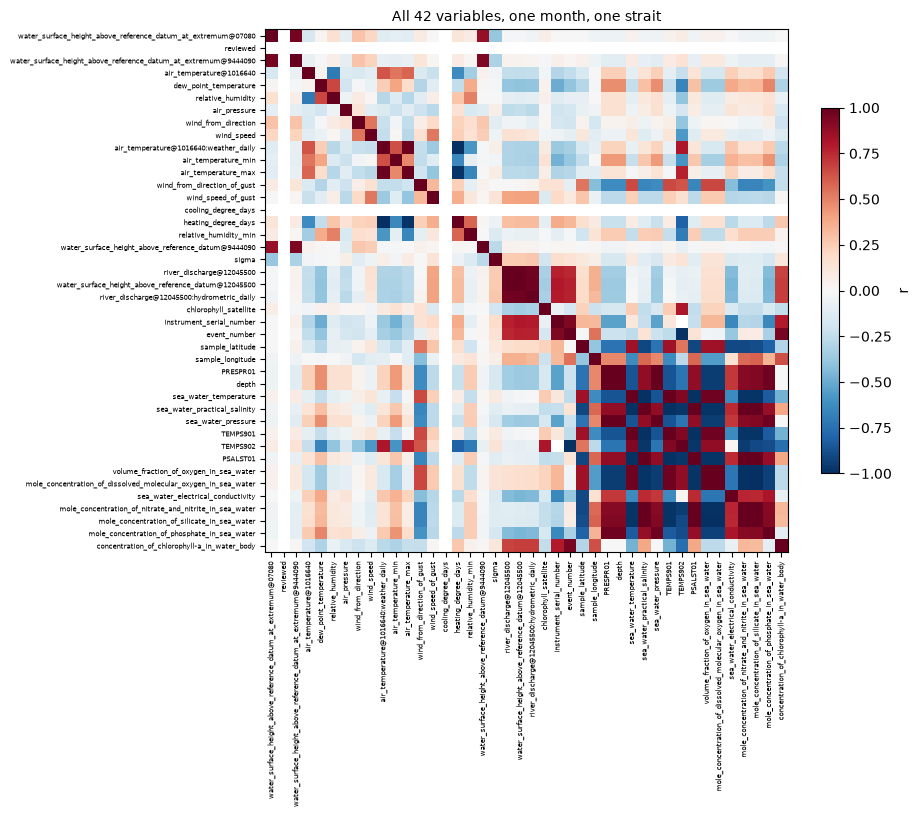

In [6]:
corr = X[numeric].corr()
fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(numeric)), numeric, rotation=90, fontsize=5.2)
ax.set_yticks(range(len(numeric)), numeric, fontsize=5.2)
fig.colorbar(im, shrink=0.7, label="r")
ax.set_title(f"All {len(numeric)} variables, one month, one strait", fontsize=10)
fig.tight_layout()

The deep-red blocks are real physics and real redundancy: duplicate
temperature sensors on one rosette, stage moving with discharge, nutrient chemistry moving
with salinity. But some of the strongest reds are **manufactured** — a nine-sample bottle
cast interpolated onto 729 hourly cells will correlate with almost anything.

That is what the pre-resample observation counts are for. **Model features must rest on real
observations**, not on cells a resampler filled in: keep columns with enough actual
measurements to speak at hourly cadence, and let `drop_correlated()` prune what remains —
it audits every drop and, on a tie, keeps the column resting on more observations.

In [7]:
RESPONSE = "water_surface_height_above_reference_datum@9444090"   # Port Angeles, observed

dense = [c for c in numeric
         if samples.get(c, 0) >= 76                # >= the sparsest real hourly-scale series
         and c not in (RESPONSE, "sigma", "reviewed")]
features = omnisea.drop_correlated(X[dense], threshold=0.9)
print(f"{len(numeric)} variables -> {len(dense)} with enough real observations "
      f"-> {features.shape[1]} after pruning\n")
for column, why in features.attrs["omnisea_dropped"].items():
    print(f"  dropped {column}\n          {why}")

42 variables -> 10 with enough real observations -> 8 after pruning

  dropped water_surface_height_above_reference_datum@12045500
          |r|=0.9973 with river_discharge@12045500 over 721 samples [ft vs ft3 s-1]; kept column rests on 2881 observation(s)
  dropped water_surface_height_above_reference_datum_at_extremum@07080
          |r|=0.9548 with water_surface_height_above_reference_datum_at_extremum@9444090 over 722 samples; kept column rests on 98 observation(s)


/var/folders/hd/3rqqvs_j7ns9lp665gvzv0_w0000gn/T/ipykernel_8129/3523832239.py:6: UserWarning: drop_correlated() removed 1 column(s) in favour of a column with different units: water_surface_height_above_reference_datum@12045500 (ft) dropped for river_discharge@12045500 (ft3 s-1). Correlation cannot tell a duplicate from a substitute — check these are the same quantity, and pin the one you want with keep=.
  features = omnisea.drop_correlated(X[dense], threshold=0.9)


Every drop names its reason: the river's stage column goes because it is
discharge in different clothes (r = 0.997 at the same gauge), and of the two countries'
harmonic tide predictions the one resting on fewer real extrema goes.

## 5. One model over everything that survived

Predict the observed Port Angeles water level from every surviving feature at once — a random
forest, so each variable reports its importance. Held-out split; the score is earned on hours
the model never saw.

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

kept = list(features.columns)
M = features.join(X[RESPONSE]).dropna()
X_train, X_test, y_train, y_test = train_test_split(
    M[kept], M[RESPONSE], test_size=0.3, random_state=0)
model = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1)
model.fit(X_train, y_train)

print(f"{len(M)} hours, {len(kept)} features; scored on {len(X_test)} held out")
print(f"held-out R2  = {r2_score(y_test, model.predict(X_test)):.3f}")
print(f"held-out MAE = {mean_absolute_error(y_test, model.predict(X_test)):.3f} m")

714 hours, 8 features; scored on 215 held out
held-out R2  = 0.895
held-out MAE = 0.175 m


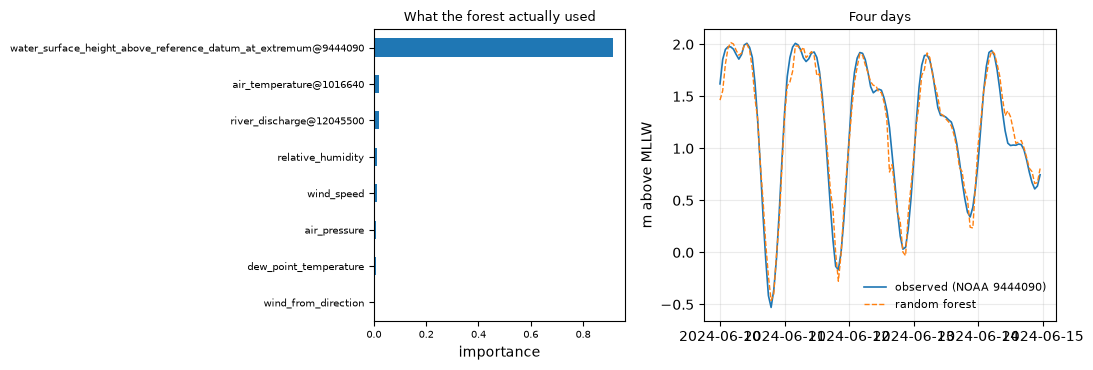

In [9]:
importance = pd.Series(model.feature_importances_, index=kept).sort_values()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.4]})
importance.plot.barh(ax=ax1, fontsize=7)
ax1.set_title("What the forest actually used", fontsize=9); ax1.set_xlabel("importance")
window = M.loc["2024-06-10":"2024-06-14"]
ax2.plot(window.index, window[RESPONSE], lw=1.2, label="observed (NOAA 9444090)")
ax2.plot(window.index, model.predict(window[kept]), lw=1.0, ls="--", label="random forest")
ax2.set_ylabel("m above MLLW"); ax2.legend(frameon=False, fontsize=8)
ax2.set_title("Four days", fontsize=9); ax2.grid(alpha=0.25)
fig.tight_layout()

The importances are the physics ranked: the harmonic prediction carries the
tide, and everything else — pressure, wind, river, temperature — divides the residual. A
model handed *everything* and finding *the right things* is the end-to-end check that six
agencies' times, units and datums all lined up.

## 6. Cite all of it

Six organizations, two countries, one block — including the stations that matched but had
nothing to give this month, named as such rather than silently absent.

In [10]:
print(omnisea.citation(tree))

Data were retrieved with omnisea 0.1.0 on 2026-08-28T05:02:57+00:00 from 9 source(s) across 6 station(s), covering 2024-06-01 to 2024-07-01.

  Institute of Ocean Sciences — cioos_pacific_tabledap (1 station(s), 2024-06-01 to 2024-06-29): IOS Rosette Bottle Data (IOS_BOT_Profiles). Licence: The data may be used and redistributed for free but is not intended
for legal use, since it may contain inaccuracies. Neither the data
Contributor, ERD, NOAA, nor the United States Government, nor any
of their employees or contractors, makes any warranty, express or
implied, including warranties of merchantability and fitness for a
particular purpose, or assumes any legal liability for the accuracy,
completeness, or usefulness, of this information.. Terms: ???
  Fisheries and Oceans Canada / Canadian Hydrographic Service — dfo_tides (1 station(s), 2024-06-01 to 2024-06-30): Pedder Bay (07080). Licence: Fisheries and Oceans Canada — Open Government Licence – Canada. Terms: https://open.canada.ca/en/o

## Recap

* **No `providers=` anywhere**: one bare `discover()` swept every registered source; the
  catalogue-first workflow turned a billion-row estimate into one fetch of the nearest
  station per source.
* **Every kind of thing the region holds** rode in: six-minute and fifteen-minute
  observations, hourly and daily summaries, predicted extrema from two countries, bottle-cast
  chemistry, and a satellite pixel sampled from a lazy grid.
* **Every variable** landed in one hourly matrix with native units and real observation
  counts — and those counts, not post-resample coverage, decided what was allowed to feed the
  model. The correlation heatmap showed why: interpolation manufactures correlation.
* One pruned model over everything that survived, scored held-out, importances ranking the
  physics.
* One `citation()` naming six institutions, licences included.

The companion notebook, `quickstart_model.ipynb`, walks the same pipeline slowly with three
named sources; the five regional notebooks go deeper still.